# Decision Tree Classification on Carseats Dataset

## Objective
Use the Carseats dataset to build a Decision Tree Classifier to predict 'High' sales (Sales > 8).  
This notebook demonstrates data loading, preprocessing, model training, and evaluation.

## Dataset
The dataset contains 400 observations on car seat sales and various demographic/store attributes.
Source: [Kaggle/GitHub](https://github.com/kirenz/datasets/blob/master/Carseats.csv)

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set plot style
sns.set(style="whitegrid")

## 1. Data Loading
We load the dataset directly from a URL to ensure accessibility.

In [2]:
def load_data():
    """
    Loads the Carseats dataset from a remote URL.
    Returns:
        pd.DataFrame: The loaded dataset.
    """
    url = "https://raw.githubusercontent.com/kirenz/datasets/master/Carseats.csv"
    try:
        df = pd.read_csv(url)
        print("Data loaded successfully.")
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

df = load_data()
df.head()

Data loaded successfully.


,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,1,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,2,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,3,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,4,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,5,4.15,141,64,3,340,128,Bad,38,13,Yes,No


## 2. Data Preprocessing
- Create the target variable `High`: 'Yes' if `Sales` > 8, else 'No'.
- Encode categorical variables (`ShelveLoc`, `Urban`, `US`).
- Remove the original `Sales` column to avoid data leakage.

In [3]:
def preprocess_data(df):
    """
    Preprocesses the dataframe for the decision tree.
    Args:
        df (pd.DataFrame): Raw dataframe.
    Returns:
        X (pd.DataFrame): Features.
        y (pd.Series): Target variable.
    """
    data = df.copy()
    
    # 1. Create Target Variable 'High'
    data['High'] = data['Sales'].apply(lambda x: 'Yes' if x > 8 else 'No')
    
    # 2. Encode Categorical Variables
    # Standard mapping for binary and ordinal variables
    data['Urban'] = data['Urban'].map({'Yes': 1, 'No': 0})
    data['US'] = data['US'].map({'Yes': 1, 'No': 0})
    data['ShelveLoc'] = data['ShelveLoc'].map({'Bad': 0, 'Medium': 1, 'Good': 2})
    
    # 3. Feature Selection
    # Drop 'Sales' (source of target) and 'High' (target itself) from features
    X = data.drop(['Sales', 'High'], axis=1)
    y = data['High']
    
    return X, y

X, y = preprocess_data(df)
print("Features shape:", X.shape)
X.head()

Features shape: (400, 11)


,Unnamed: 0,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,1,138,73,11,276,120,0,42,17,1,1
1,2,111,48,16,260,83,2,65,10,1,1
2,3,113,35,10,269,80,1,59,12,1,1
3,4,117,100,4,466,97,1,55,14,1,1
4,5,141,64,3,340,128,0,38,13,1,0


## 3. Exploratory Data Analysis (EDA)
Briefly check the data structure and specific columns.

In [4]:
print(X.info())
print("\nTarget Distribution:")
print(y.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   400 non-null    int64
 1   CompPrice    400 non-null    int64
 2   Income       400 non-null    int64
 3   Advertising  400 non-null    int64
 4   Population   400 non-null    int64
 5   Price        400 non-null    int64
 6   ShelveLoc    400 non-null    int64
 7   Age          400 non-null    int64
 8   Education    400 non-null    int64
 9   Urban        400 non-null    int64
 10  US           400 non-null    int64
dtypes: int64(11)
memory usage: 34.5 KB
None

Target Distribution:
High
No     236
Yes    164
Name: count, dtype: int64


## 4. Model Building
- Split data into training (80%) and testing (20%) sets.
- Initialize and train a `DecisionTreeClassifier`.

In [5]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Model
# random_state ensures reproducibility
# max_depth=3 limits the complexity of the tree for better visualization
dtree = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train Model
dtree.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 5. Model Evaluation
Evaluate the performance using Accuracy, Confusion Matrix, and Classification Report.

In [6]:
predictions = dtree.predict(X_test)

acc = accuracy_score(y_test, predictions)
cm = confusion_matrix(y_test, predictions)
report = classification_report(y_test, predictions)

print(f"Accuracy: {acc:.4f}")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

Accuracy: 0.7875

Confusion Matrix:
 [[35  8]
 [ 9 28]]

Classification Report:
               precision    recall  f1-score   support

          No       0.80      0.81      0.80        43
         Yes       0.78      0.76      0.77        37

    accuracy                           0.79        80
   macro avg       0.79      0.79      0.79        80
weighted avg       0.79      0.79      0.79        80



## 6. Visualization
Visualize the Decision Tree structure.

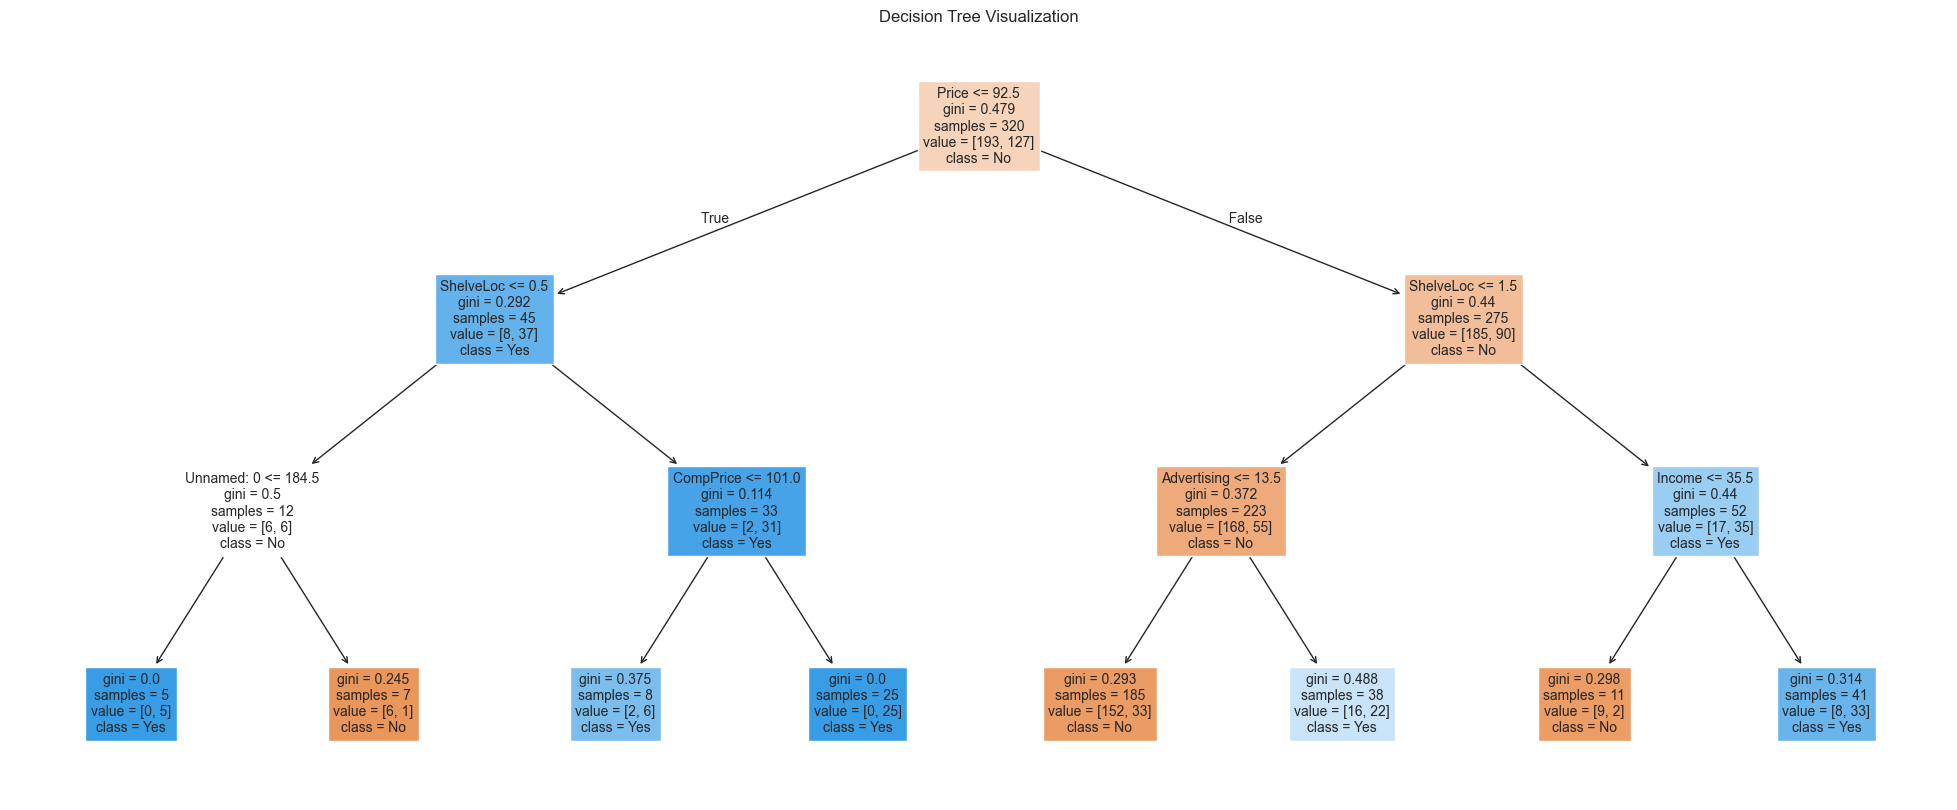

In [7]:
plt.figure(figsize=(25, 10))
plot_tree(dtree, filled=True, feature_names=X.columns, class_names=['No', 'Yes'], fontsize=10)
plt.title("Decision Tree Visualization")
plt.show()

## Conclusion
The decision tree successfully classifies 'High' sales based on store and demographic attributes.